Total MAE: 0.09080813013127609


ValueError: invalid literal for int() with base 10: 'Q1'

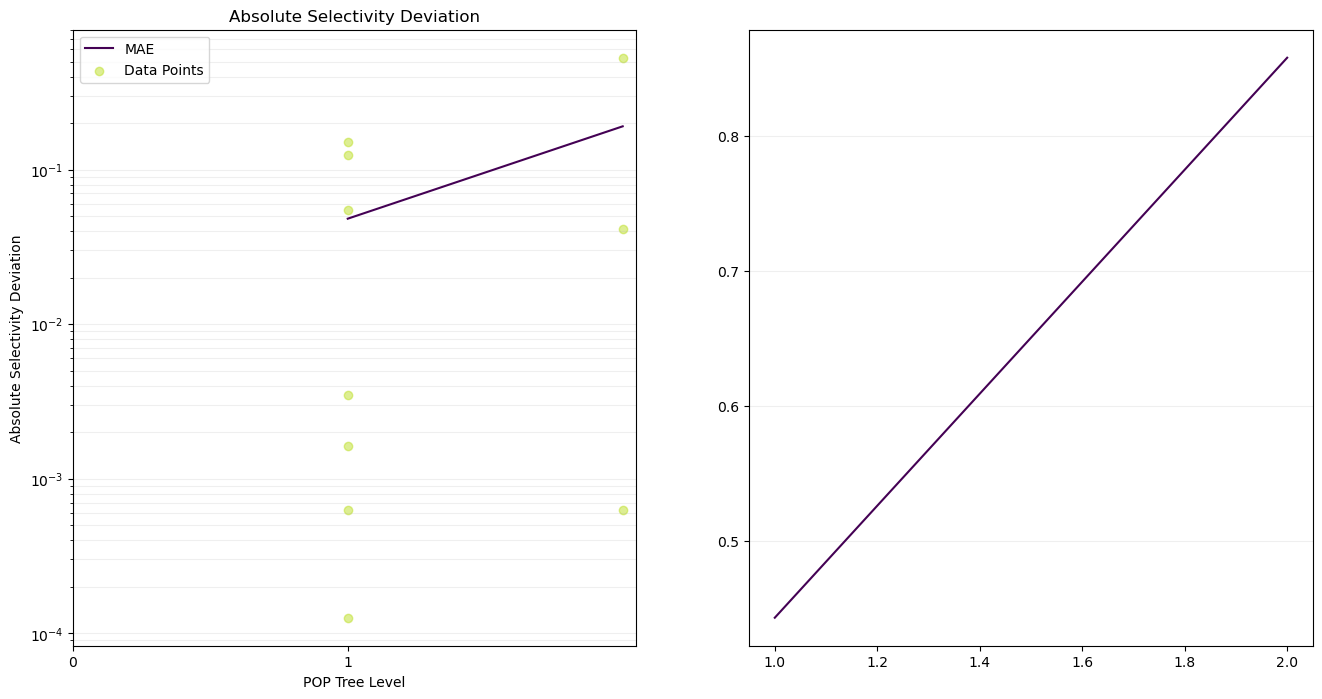

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the data
with open('data/fdbs_performance/selectivity_per_level.json', 'r') as f:
    data = json.load(f)

colors = plt.cm.viridis(np.linspace(0, 0.9, 3))
rainbow = plt.cm.gist_rainbow(np.linspace(0, 1, 6))

# Extract metrics
scatter_level = []
scatter_data = []
scatter_data_percent = []
per_level = {}
per_level_percent = {}

smape = 0
smape_count = 0

query_lines = {}

for i, entry in enumerate(data):
    q_id = entry['query']
    query_lines[q_id] = {'levels': [], 'smapes': []}
    for j, query in enumerate(entry['selectivityPerStage']):
        lvl = query['level']
        pred = query['predicted']
        act = query['actual']
        
        level = per_level.get(lvl, [])
        level.append(query['absoluteDiff'])
        per_level[lvl] = level
        
        level_in_percent = per_level_percent.get(query['level'], [])
        
        denom = abs(act) + abs(pred)
        diff_percent = (abs(pred - act) / denom) if denom != 0 else 0
        smape_val = diff_percent * 2
        
        level_in_percent.append(diff_percent)
        per_level_percent[lvl] = level_in_percent
        
        scatter_level.append(lvl)
        scatter_data.append(query['absoluteDiff'])
        scatter_data_percent.append(diff_percent)
        
        smape += diff_percent
        smape_count += 1
        
        query_lines[q_id]['levels'].append(lvl)
        query_lines[q_id]['smapes'].append(smape_val)

total = 0
per_level_avg = {}
for i, entry in per_level.items():
    total += np.sum(entry)
    
    average = np.average(entry)
    per_level_avg[i] = average

per_level_percent_avg = {}
for i, entry in per_level_percent.items():
    items = np.sum(entry)
    per_level_percent_avg[i] =  (2/ len(entry)) * items

print(f"Total MAE: {total / smape_count}")

# Set up the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.yaxis.grid(True, which="both", ls="-", alpha=0.2, zorder=1)
ax1.plot(per_level_avg.keys(), per_level_avg.values(), label='MAE', color=colors[0])

ax1.scatter(scatter_level, scatter_data, label='Data Points', color=colors[2], alpha=0.5)

ax1.set_xticks(np.arange(0, len(per_level_percent_avg.keys()), 1))
ax1.set_title('Absolute Selectivity Deviation')
ax1.set_ylabel('Absolute Selectivity Deviation')
ax1.set_xlabel('POP Tree Level')
ax1.set_yscale('log')
ax1.legend()

ax2.yaxis.grid(True, which="both", ls="-", alpha=0.2, zorder=1)

ax2.plot(per_level_percent_avg.keys(), per_level_percent_avg.values(), label='sMAPE', color=colors[0])

for q_id, vals in query_lines.items():
    # Group by level and average the sMAPEs for that specific query
    unique_levels = sorted(set(vals['levels']))
    avg_smapes = []
    for l in unique_levels:
        # Get all sMAPEs for this query at this specific level
        matches = [s for lvl, s in zip(vals['levels'], vals['smapes']) if lvl == l]
        avg_smapes.append(np.mean(matches))
    
    ax2.plot(unique_levels, avg_smapes, alpha=0.3, linestyle='--', label=f'Query {q_id}', color=rainbow[int(q_id) - 1])

ax2.set_xticks(np.arange(0, len(per_level_percent_avg.keys()), 1))
ax2.set_title('Relative Selectivity Deviation')
ax2.set_ylabel('Relative Selectivity Deviation')
ax2.set_xlabel('POP Tree Level')

#set y range from 0 to 1
ax2.set_ylim(0, 2)
print(per_level_avg)
ax2.legend()

plt.savefig('images/selectivity/selectivity_accuracy.png', bbox_inches='tight', pad_inches=0.1)
plt.show()
